# AudioTexture - Colab Model Testing
# This notebook tests genre classification models on Mel-spectrogram images.
# Workflow:
# 1) Set runtime to GPU in Colab
# 2) Mount Google Drive
# 3) Load spectrogram dataset from processed_data/spectrograms
# 4) Train/evaluate a baseline CNN
# 5) Optionally run transfer learning (EfficientNetV2-B0)
# 6) Train Resnet with frozen backbone
# 7) Train Ensemble of the models we trained

In [1]:
# Environment check
import os
import platform
import tensorflow as tf

print('Python:', platform.python_version())
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

Python: 3.12.13
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print('Running in Colab:', IN_COLAB)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab: True


In [3]:
# Paths and directories
from pathlib import Path

if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/Senior Project 2')
else:
    PROJECT_ROOT = Path.cwd()

SPECTROGRAM_DIR = PROJECT_ROOT / 'processed_data' / 'spectrograms'
CHECKPOINT_DIR = PROJECT_ROOT / 'model_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('SPECTROGRAM_DIR exists:', SPECTROGRAM_DIR.exists())

PROJECT_ROOT: /content/drive/MyDrive/Senior Project 2
SPECTROGRAM_DIR exists: True


In [4]:
# Dataset parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.2

In [5]:
# Build train/validation datasets from directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    SPECTROGRAM_DIR,
    labels='inferred',
    label_mode='categorical',
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    SPECTROGRAM_DIR,
    labels='inferred',
    label_mode='categorical',
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print('Detected classes:', class_names)
print("Training shape:", train_ds.element_spec)
print("Validation shape:", val_ds.element_spec)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1024).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 3866 files belonging to 8 classes.
Using 3093 files for training.
Found 3866 files belonging to 8 classes.
Using 773 files for validation.
Detected classes: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Training shape: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))
Validation shape: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))


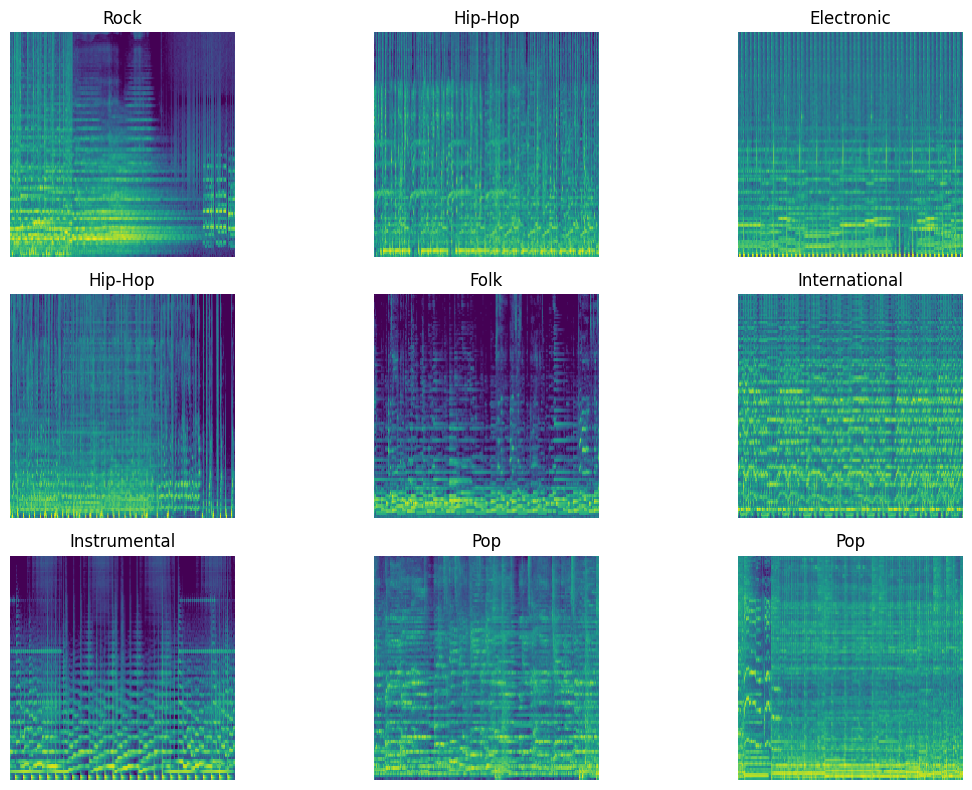

In [6]:
# Visual sanity check
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[tf.argmax(labels[i]).numpy()])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Baseline CNN model
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,688 (436.28 KB)

 Trainable params: 111,240 (434.53 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Train baseline CNN
EPOCHS = 15

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'baseline_best.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 79s 679ms/step - accuracy: 0.3973 - loss: 1.6661 - val_accuracy: 0.1320 - val_loss: 2.4723
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4943 - loss: 1.4471 - val_accuracy: 0.0841 - val_loss: 4.5071
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5144 - loss: 1.3707 - val_accuracy: 0.0776 - val_loss: 7.8239
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5357 - loss: 1.3187 - val_accuracy: 0.0776 - val_loss: 9.3942
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5441 - loss: 1.2782 - val_accuracy: 0.0789 - val_loss: 7.4648


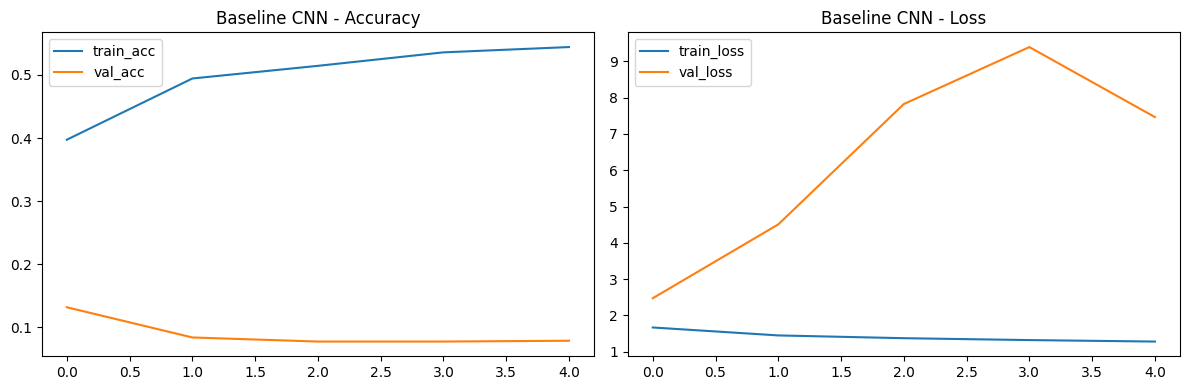

In [9]:
# Plot training curves
def plot_history(history, title='Training Curves'):
    h = history.history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h['accuracy'], label='train_acc')
    plt.plot(h['val_accuracy'], label='val_acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h['loss'], label='train_loss')
    plt.plot(h['val_loss'], label='val_loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, title='Baseline CNN')

In [10]:
# Optional: Transfer learning model (lighter than EfficientNetV2-S)
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Lambda(tf.keras.applications.efficientnet_v2.preprocess_input),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,929,560 (22.62 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [11]:
# Optional: Train transfer model
USE_TRANSFER = False  # Set True to run this block

if USE_TRANSFER:
    history_transfer = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / 'transfer_best.keras'),
                monitor='val_accuracy',
                save_best_only=True
            )
        ]
    )
    plot_history(history_transfer, title='Transfer Learning')
else:
    print('Set USE_TRANSFER=True to train transfer model.')

Set USE_TRANSFER=True to train transfer model.


In [12]:
# Final evaluation helper
def evaluate_model(model, name='model'):
    loss, acc = model.evaluate(val_ds, verbose=0)
    print(f'{name} -> val_loss: {loss:.4f}, val_accuracy: {acc:.4f}')

evaluate_model(baseline_model, 'Baseline CNN')
if 'transfer_model' in globals() and USE_TRANSFER:
    evaluate_model(transfer_model, 'Transfer Model')

Baseline CNN -> val_loss: 2.4723, val_accuracy: 0.1320


## Refinement Path (Post-Baseline)
Use this section to train a stronger model with:
- Class-weighting to address genre imbalance
- Data augmentation for better generalization
- Label smoothing + L2 regularization
- ReduceLROnPlateau + EarlyStopping
- Confusion matrix to inspect per-class errors

In [13]:
# Build refinement utilities: class weights + augmented regularized model
import numpy as np
from collections import Counter

# Compute class counts from directory (same source as dataset split)
class_counts = {}
for i, name in enumerate(class_names):
    class_dir = SPECTROGRAM_DIR / name
    class_counts[i] = len(list(class_dir.glob('*.png')))

total = sum(class_counts.values())
num_classes = len(class_names)

# Inverse-frequency class weights (normalized around 1.0)
class_weight = {i: total / (num_classes * max(1, c)) for i, c in class_counts.items()}
print('Class counts:', {class_names[i]: c for i, c in class_counts.items()})
print('Class weights:', {class_names[i]: round(class_weight[i], 3) for i in class_weight})

# Data augmentation tailored for spectrogram images
data_augmentation = keras.Sequential([
    layers.RandomTranslation(0.03, 0.05),
    layers.RandomZoom(0.10),
    layers.GaussianNoise(0.02),
])

# Refined CNN with stronger regularization
refined_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),
    data_augmentation,

    layers.Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.Conv2D(128, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.35),

    layers.Conv2D(192, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(160, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation='softmax')
])

refined_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

refined_model.summary()

Class counts: {'Electronic': 529, 'Experimental': 287, 'Folk': 772, 'Hip-Hop': 873, 'Instrumental': 150, 'International': 320, 'Pop': 574, 'Rock': 361}
Class weights: {'Electronic': 0.914, 'Experimental': 1.684, 'Folk': 0.626, 'Hip-Hop': 0.554, 'Instrumental': 3.222, 'International': 1.51, 'Pop': 0.842, 'Rock': 1.339}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 192)    │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │        30,880 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 348,040 (1.33 MB)

 Trainable params: 347,208 (1.32 MB)

 Non-trainable params: 832 (3.25 KB)

Epoch 1/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.2929 - loss: 1.9133 - val_accuracy: 0.1138 - val_loss: 2.4708 - learning_rate: 7.0000e-04
Epoch 2/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3773 - loss: 1.7590 - val_accuracy: 0.2083 - val_loss: 3.0183 - learning_rate: 7.0000e-04
Epoch 3/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4013 - loss: 1.7645
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4016 - loss: 1.7090 - val_accuracy: 0.2096 - val_loss: 5.0270 - learning_rate: 7.0000e-04
Epoch 4/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4352 - loss: 1.6503 - val_accuracy: 0.2186 - val_loss: 3.4120 - learning_rate: 3.5000e-04
Epoch 5/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4483 - loss: 1.6396
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4442 - loss: 

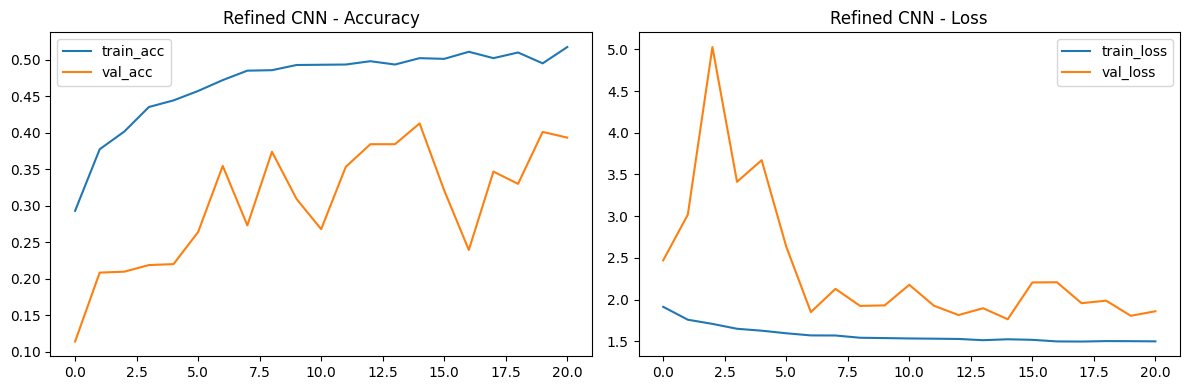

In [14]:
# Train refined model
REFINED_EPOCHS = 25

refined_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'refined_best.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

history_refined = refined_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=REFINED_EPOCHS,
    callbacks=refined_callbacks,
    class_weight=class_weight
)

plot_history(history_refined, title='Refined CNN')

Refined CNN -> val_loss: 1.7647, val_accuracy: 0.4127
Best val_accuracy -> baseline: 0.1320, refined: 0.4127


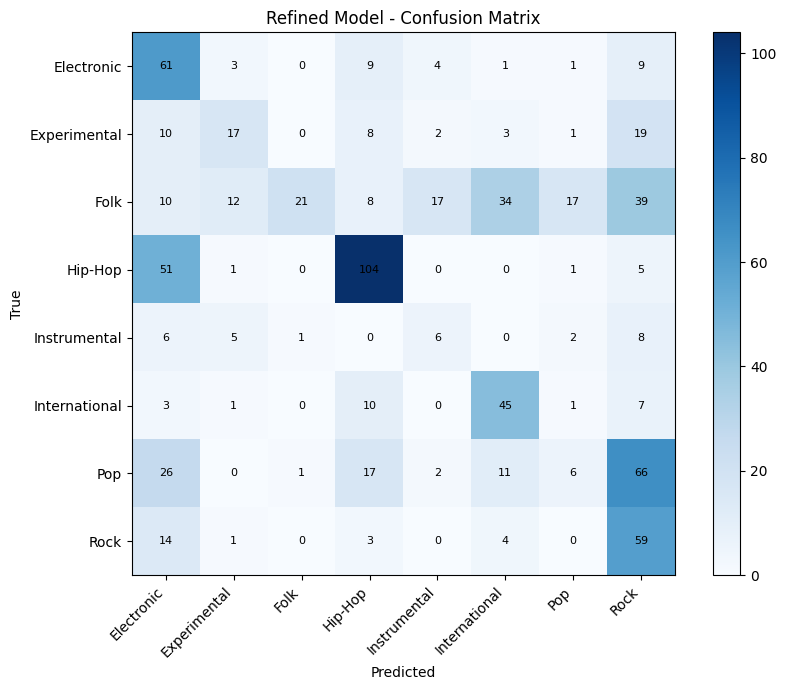

In [37]:
# Compare baseline vs refined + confusion matrix
evaluate_model(refined_model, 'Refined CNN')

if 'history_baseline' in globals():
    best_base = max(history_baseline.history.get('val_accuracy', [0]))
    best_ref = max(history_refined.history.get('val_accuracy', [0]))
    print(f'Best val_accuracy -> baseline: {best_base:.4f}, refined: {best_ref:.4f}')

# Confusion matrix for refined model
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = refined_model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap='Blues')
plt.title('Refined Model - Confusion Matrix')
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'refined_confusion_matrix.png', dpi=300)
plt.show()


## Advanced Model Improvements
- **Fine-tuned Transfer Learning**: Unfreeze top blocks of EfficientNetV2-B0 + adaptive learning rates
- **Ensemble Voting**: Combine baseline, refined, and fine-tuned transfer models
- **ResNet50 Alternative**: Test with deeper pre-trained backbone
- **Hybrid Architecture**: High-capacity custom model with skip connections

In [16]:
# Fine-tuned Transfer Learning with Adaptive Unfreezing
# Start frozen, then progressively unfreeze top layers + fine-tune

# Load EfficientNetV2-B0 base again
base_tuned = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Build model with stronger custom head
finetuned_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Lambda(tf.keras.applications.efficientnet_v2.preprocess_input),
    data_augmentation,
    base_tuned,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='finetuned_efficientnet')

# Phase 1: Train with frozen backbone
base_tuned.trainable = False
finetuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("Phase 1: Training with frozen backbone...")
history_frozen = finetuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ],
    class_weight=class_weight,
    verbose=1
)

# Phase 2: Unfreeze top 50% of backbone layers + fine-tune
base_tuned.trainable = True
for layer in base_tuned.layers[:-len(base_tuned.layers)//2]:
    layer.trainable = False

finetuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Much lower LR for fine-tuning
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("\nPhase 2: Fine-tuning top layers...")
history_finetuned = finetuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(CHECKPOINT_DIR / 'finetuned_best.keras'),
            monitor='val_accuracy',
            save_best_only=True
        )
    ],
    class_weight=class_weight,
    verbose=1
)

evaluate_model(finetuned_model, 'Fine-tuned EfficientNetV2-B0')

Phase 1: Training with frozen backbone...
Epoch 1/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.3139 - loss: 2.1256 - val_accuracy: 0.2937 - val_loss: 1.8786
Epoch 2/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3922 - loss: 1.8495 - val_accuracy: 0.4799 - val_loss: 1.5621
Epoch 3/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4361 - loss: 1.6946 - val_accuracy: 0.4903 - val_loss: 1.5194
Epoch 4/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4352 - loss: 1.6769 - val_accuracy: 0.4295 - val_loss: 1.6491
Epoch 5/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4640 - loss: 1.6021 - val_accuracy: 0.4191 - val_loss: 1.6634
Epoch 6/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4785 - loss: 1.5758 - val_accuracy: 0.5226 - val_loss: 1.4495
Epoch 7/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4888 - loss: 1.5568 - val_accuracy: 0.5110 - val_loss: 1.5108
Epoch 8/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5118 - loss

ENSEMBLE EVALUATION

Ensemble Accuracy: 0.4994
Baseline             -> val_accuracy: 0.1320
Refined              -> val_accuracy: 0.4127
Fine-tuned           -> val_accuracy: 0.5213


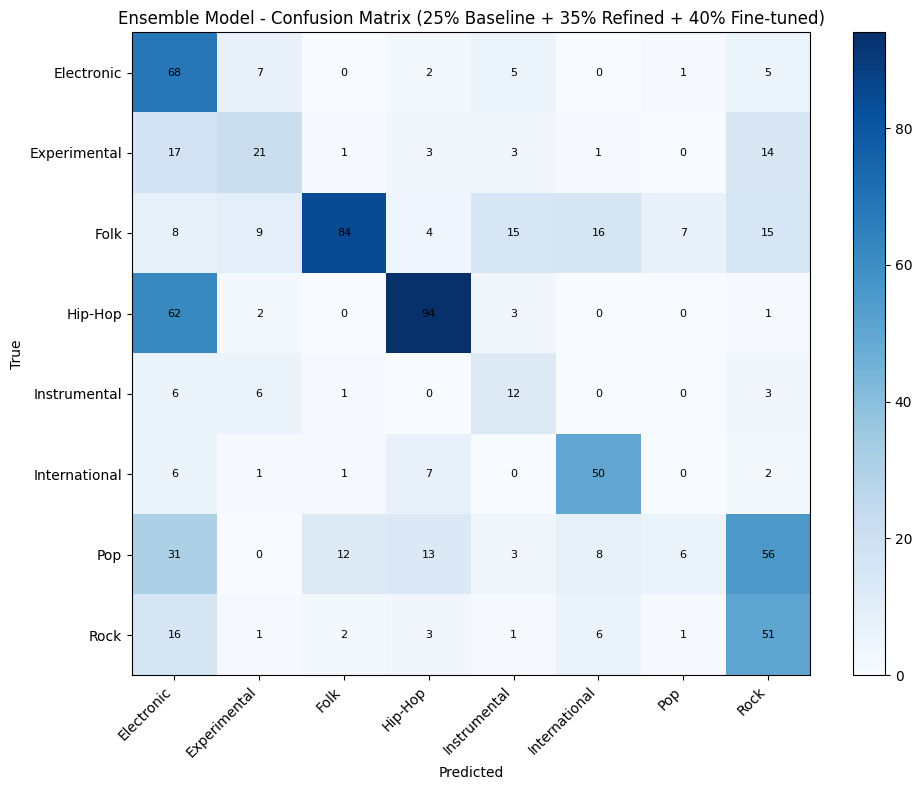

In [39]:
# Ensemble Voting: Combine Baseline, Refined, and Fine-tuned Models
# Each model votes; highest aggregate confidence wins

def ensemble_predict(models, dataset, names, weights=None):
    """
    Combine predictions from multiple models using weighted voting.
    weights: list of weights for each model (default: equal)
    """
    if weights is None:
        weights = [1.0] * len(models)
    
    all_votes = None
    
    for model, name, weight in zip(models, names, weights):
        y_pred_model = []
        for x_batch, _ in dataset:
            preds = model.predict(x_batch, verbose=0)
            y_pred_model.append(preds)
        
        y_pred_model = np.concatenate(y_pred_model, axis=0)
        if all_votes is None:
            all_votes = weight * y_pred_model
        else:
            all_votes += weight * y_pred_model
    
    # Normalize
    all_votes /= sum(weights)
    
    return all_votes, np.argmax(all_votes, axis=1)

# Evaluate ensemble on validation set
print("=" * 60)
print("ENSEMBLE EVALUATION")
print("=" * 60)

ensemble_preds, ensemble_labels = ensemble_predict(
    [baseline_model, refined_model, finetuned_model],
    val_ds,
    ['Baseline', 'Refined', 'Fine-tuned'],
    weights=[0.25, 0.35, 0.40]  # Bias towards fine-tuned
)

# Compute ensemble accuracy
y_true_list = []
for _, y_batch in val_ds:
    y_true_list.extend(np.argmax(y_batch.numpy(), axis=1))
y_true_ensemble = np.array(y_true_list)

ensemble_accuracy = np.mean(ensemble_labels == y_true_ensemble)
print(f'\nEnsemble Accuracy: {ensemble_accuracy:.4f}')

# Individual model accuracies for comparison
for model, name in zip([baseline_model, refined_model, finetuned_model], 
                       ['Baseline', 'Refined', 'Fine-tuned']):
    loss, acc = model.evaluate(val_ds, verbose=0)
    print(f'{name:20s} -> val_accuracy: {acc:.4f}')

# Confusion matrix for ensemble
cm_ensemble = tf.math.confusion_matrix(y_true_ensemble, ensemble_labels, num_classes=num_classes).numpy()

plt.figure(figsize=(10, 8))
plt.imshow(cm_ensemble, cmap='Blues', aspect='auto')
plt.title('Ensemble Model - Confusion Matrix (25% Baseline + 35% Refined + 40% Fine-tuned)')
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_ensemble[i, j], ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'ensemble_confusion_matrix.png', dpi=300)
plt.show()


In [18]:
# Alternative: ResNet50-based Transfer Learning
# Deeper architecture for better feature extraction

base_resnet = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

resnet_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Lambda(tf.keras.applications.resnet.preprocess_input),
    data_augmentation,
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='resnet50_transfer')

# Train ResNet (frozen first, then fine-tune)
base_resnet.trainable = False
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("ResNet50: Training with frozen backbone...")
history_resnet_frozen = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ],
    class_weight=class_weight,
    verbose=0
)

# Fine-tune top layers
base_resnet.trainable = True
for layer in base_resnet.layers[:-30]:  # Freeze all but top 30 layers
    layer.trainable = False

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("ResNet50: Fine-tuning top layers...")
history_resnet_tuned = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,
            min_lr=1e-7,
            verbose=0
        ),
    ],
    class_weight=class_weight,
    verbose=0
)

evaluate_model(resnet_model, 'Fine-tuned ResNet50')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
ResNet50: Training with frozen backbone...
ResNet50: Fine-tuning top layers...
Fine-tuned ResNet50 -> val_loss: 1.4371, val_accuracy: 0.5666


In [19]:
# Hybrid Architecture: Custom Deep Network with Skip Connections
# High-capacity model with residual-style skip connections

def residual_block(x, filters, kernel_size=3, dropout=0.3):
    """Residual block: Conv -> BN -> ReLU -> Dropout, with skip connection"""
    shortcut = x
    
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Skip connection with 1x1 conv if dimensions don't match
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout)(x)
    
    return x

# Build hybrid model with functional API for flexibility
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = layers.Rescaling(1./255)(inputs)
x = data_augmentation(x)

# Stack 1: 32 filters with skip
x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 32, dropout=0.25)
x = layers.MaxPooling2D()(x)

# Stack 2: 64 filters with skip
x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 64, dropout=0.30)
x = layers.MaxPooling2D()(x)

# Stack 3: 128 filters with skip
x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 128, dropout=0.35)
x = layers.MaxPooling2D()(x)

# Stack 4: 256 filters with skip
x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 256, dropout=0.40)

# Global average pooling + dense head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

hybrid_model = keras.Model(inputs=inputs, outputs=outputs, name='hybrid_resnet_style')

hybrid_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("Hybrid Architecture Summary:")
hybrid_model.summary()

# Train hybrid model
print("\nTraining Hybrid Model...")
history_hybrid = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(CHECKPOINT_DIR / 'hybrid_best.keras'),
            monitor='val_accuracy',
            save_best_only=True
        )
    ],
    class_weight=class_weight,
    verbose=1
)

evaluate_model(hybrid_model, 'Hybrid Skip-Connection Model')

Hybrid Architecture Summary:


Model: "hybrid_resnet_style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_9[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ rescaling_4[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │        864 │ sequential_2[3][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 224, 224,  │      9,216 │ re_lu_4[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 224, 224,  │          0 │ re_lu_5[0][0]     │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │      9,216 │ dropout_13[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 224, 224,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 224, 224,  │          0 │ re_lu_6[0][0]     │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 112, 112,  │          0 │ dropout_14[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 112, 112,  │     18,432 │ max_pooling2d_6[

 Total params: 2,061,160 (7.86 MB)

 Trainable params: 2,057,768 (7.85 MB)

 Non-trainable params: 3,392 (13.25 KB)


Training Hybrid Model...
Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step - accuracy: 0.2279 - loss: 2.3648 - val_accuracy: 0.2096 - val_loss: 2.4756 - learning_rate: 7.0000e-04
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.2987 - loss: 2.0745 - val_accuracy: 0.2096 - val_loss: 3.0390 - learning_rate: 7.0000e-04
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3181 - loss: 2.0068
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.3236 - loss: 2.0028 - val_accuracy: 0.1798 - val_loss: 4.5443 - learning_rate: 7.0000e-04
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3421 - loss: 1.8750 - val_accuracy: 0.2096 - val_loss: 4.6015 - learning_rate: 3.5000e-04
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3940 - loss: 1.7977
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step 

In [20]:
# Comprehensive Model Ranking & Analysis

print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Evaluate all models
models_to_compare = [
    (baseline_model, 'Baseline CNN'),
    (refined_model, 'Refined CNN (w/ Augmentation)'),
    (finetuned_model, 'Fine-tuned EfficientNetV2-B0'),
    (resnet_model, 'Fine-tuned ResNet50'),
    (hybrid_model, 'Hybrid Skip-Connection CNN')
]

results = {}
for model, name in models_to_compare:
    loss, acc = model.evaluate(val_ds, verbose=0)
    results[name] = {'loss': loss, 'accuracy': acc}
    print(f'{name:40s} → Loss: {loss:.4f}, Accuracy: {acc:.4f}')

# Rank by accuracy
print("\n" + "-"*70)
print("RANKING BY VALIDATION ACCURACY:")
print("-"*70)
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, metrics) in enumerate(sorted_results, 1):
    print(f'{rank}. {name:40s} {metrics["accuracy"]:.4f}')

# Best model
best_name, best_metrics = sorted_results[0]
print(f"\n🏆 BEST MODEL: {best_name}")
print(f"   Validation Accuracy: {best_metrics['accuracy']:.4f}")
print(f"   Validation Loss: {best_metrics['loss']:.4f}")

# Ensemble (combine all 5 with equal weights)
print("\n" + "-"*70)
print("ALL-MODEL ENSEMBLE (Equal Weights):")
print("-"*70)

ensemble_all_preds, ensemble_all_labels = ensemble_predict(
    [model for model, _ in models_to_compare],
    val_ds,
    [name for _, name in models_to_compare],
    weights=[0.2] * 5  # Equal weights
)

ensemble_all_acc = np.mean(ensemble_all_labels == y_true_ensemble)
print(f'All-Model Ensemble Accuracy: {ensemble_all_acc:.4f}')

# Training stability comparison (val_accuracy progression)
print("\n" + "-"*70)
print("TRAINING STABILITY (Best val_accuracy achieved):")
print("-"*70)

history_dict = {
    'Baseline CNN': history_baseline,
    'Refined CNN': history_refined,
    'Fine-tuned EfficientNetV2-B0': history_finetuned,
    'Fine-tuned ResNet50': history_resnet_tuned,
    'Hybrid Skip-Connection': history_hybrid
}

for name, history in history_dict.items():
    best_val_acc = max(history.history.get('val_accuracy', [0]))
    best_epoch = np.argmax(history.history.get('val_accuracy', [0])) + 1
    print(f'{name:40s} → Best: {best_val_acc:.4f} (epoch {best_epoch})')


COMPREHENSIVE MODEL COMPARISON
Baseline CNN                             → Loss: 2.4723, Accuracy: 0.1320
Refined CNN (w/ Augmentation)            → Loss: 1.7647, Accuracy: 0.4127
Fine-tuned EfficientNetV2-B0             → Loss: 1.4761, Accuracy: 0.5213
Fine-tuned ResNet50                      → Loss: 1.4371, Accuracy: 0.5666
Hybrid Skip-Connection CNN               → Loss: 2.4756, Accuracy: 0.2096

----------------------------------------------------------------------
RANKING BY VALIDATION ACCURACY:
----------------------------------------------------------------------
1. Fine-tuned ResNet50                      0.5666
2. Fine-tuned EfficientNetV2-B0             0.5213
3. Refined CNN (w/ Augmentation)            0.4127
4. Hybrid Skip-Connection CNN               0.2096
5. Baseline CNN                             0.1320

🏆 BEST MODEL: Fine-tuned ResNet50
   Validation Accuracy: 0.5666
   Validation Loss: 1.4371

----------------------------------------------------------------------
ALL

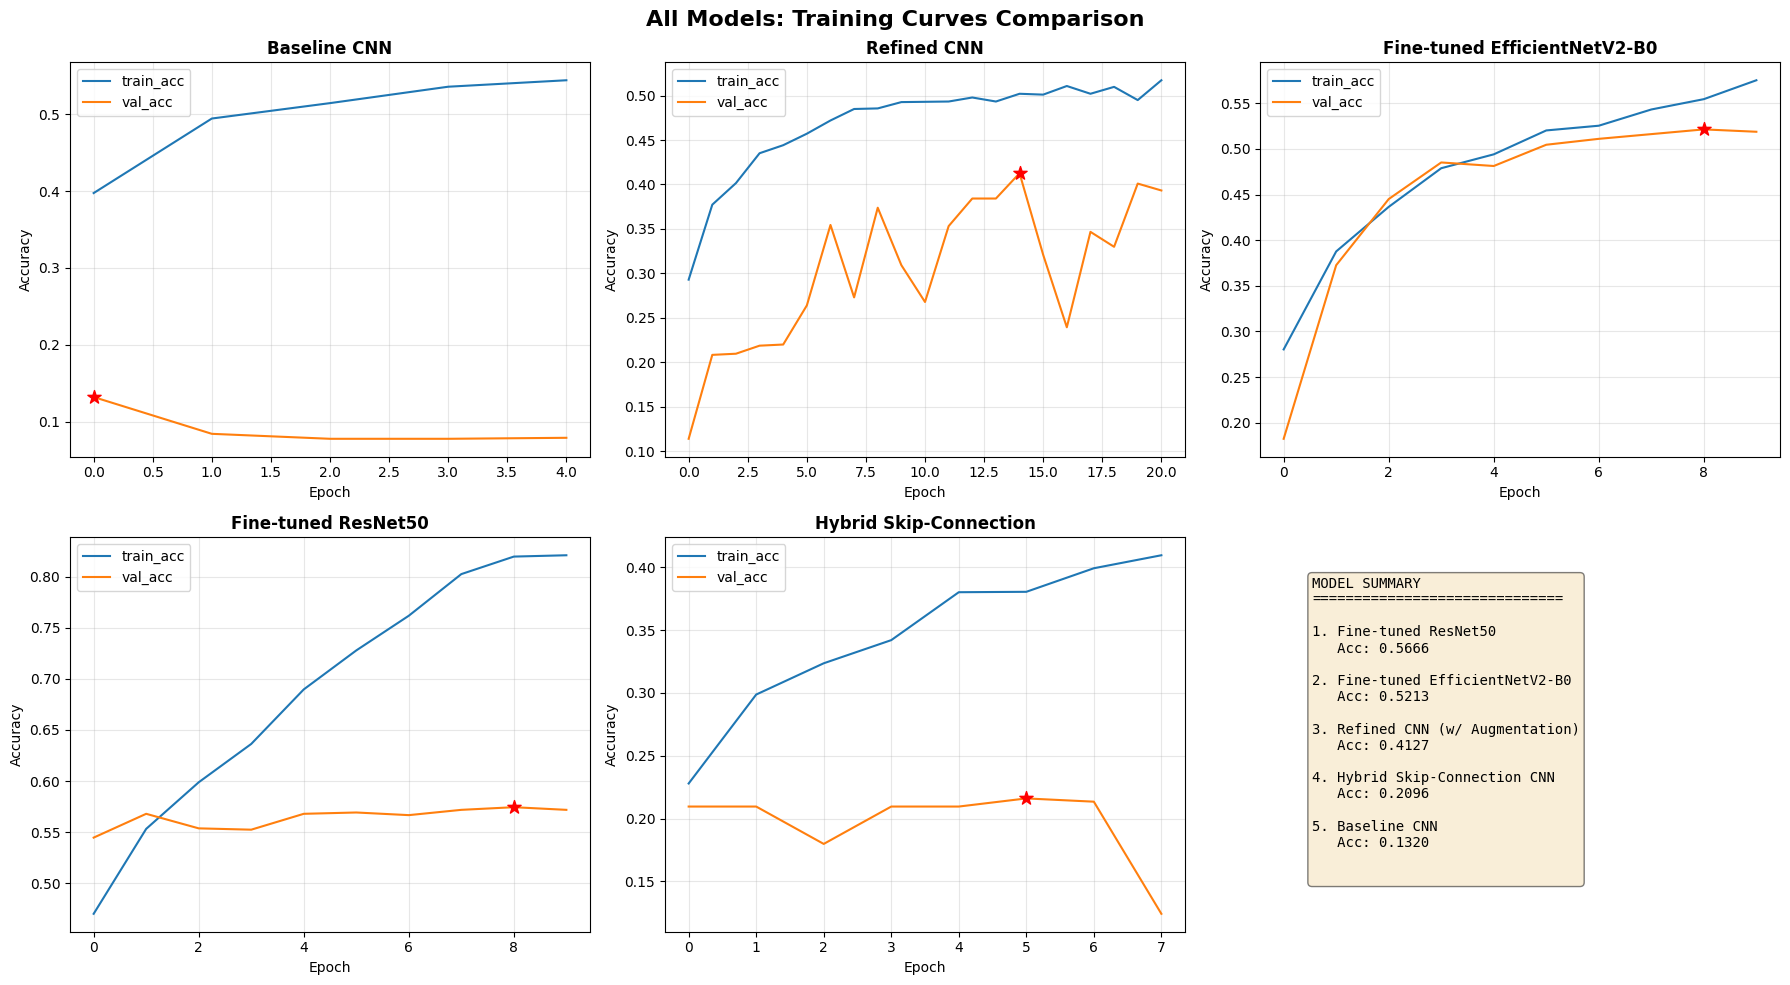

In [40]:
# Training Curves Comparison: All Models Side-by-Side

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('All Models: Training Curves Comparison', fontsize=16, fontweight='bold')

histories = [
    (history_baseline, 'Baseline CNN', axes[0, 0]),
    (history_refined, 'Refined CNN', axes[0, 1]),
    (history_finetuned, 'Fine-tuned EfficientNetV2-B0', axes[0, 2]),
    (history_resnet_tuned, 'Fine-tuned ResNet50', axes[1, 0]),
    (history_hybrid, 'Hybrid Skip-Connection', axes[1, 1])
]

for history, name, ax in histories:
    h = history.history
    
    ax.plot(h['accuracy'], label='train_acc', linewidth=1.5)
    ax.plot(h['val_accuracy'], label='val_acc', linewidth=1.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Highlight best val_acc
    best_epoch = np.argmax(h['val_accuracy'])
    best_acc = h['val_accuracy'][best_epoch]
    ax.scatter([best_epoch], [best_acc], color='red', s=100, zorder=5, marker='*')

# Summary text in the last subplot
ax_summary = axes[1, 2]
ax_summary.axis('off')
summary_text = "MODEL SUMMARY\n" + "="*30 + "\n\n"
for i, (name, metrics) in enumerate(sorted_results, 1):
    summary_text += f"{i}. {name}\n   Acc: {metrics['accuracy']:.4f}\n\n"
ax_summary.text(0.1, 0.9, summary_text, transform=ax_summary.transAxes, 
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'model_comparison_training_curves.png', dpi=300)
plt.show()


In [22]:
# Quick metrics snapshot (concise)
print('baseline_val_acc:', baseline_model.evaluate(val_ds, verbose=0)[1])
print('refined_val_acc:', refined_model.evaluate(val_ds, verbose=0)[1])
print('finetuned_effnet_val_acc:', finetuned_model.evaluate(val_ds, verbose=0)[1])
print('resnet50_val_acc:', resnet_model.evaluate(val_ds, verbose=0)[1])
print('hybrid_val_acc:', hybrid_model.evaluate(val_ds, verbose=0)[1])
print('ensemble_3_val_acc:', float(ensemble_accuracy))
print('ensemble_5_val_acc:', float(ensemble_all_acc))

baseline_val_acc: 0.1319534331560135
refined_val_acc: 0.4126778841018677
finetuned_effnet_val_acc: 0.5213454365730286
resnet50_val_acc: 0.5666235685348511
hybrid_val_acc: 0.20957309007644653
ensemble_3_val_acc: 0.49935316946959896
ensemble_5_val_acc: 0.5523932729624839


## High-Accuracy Path (Stratified + Focal Loss + Gradual Unfreezing)
This section adds a stronger training pipeline focused on stable and higher validation accuracy:
- Stratified train/validation split (balanced per class)
- Feature-engineered 3-channel input (log-mel intensity + delta-like gradients)
- Class-balanced focal loss
- Cosine-decay learning rate with warmup-like staged fine-tuning
- Weighted top-2 ensemble (ResNet50 + EfficientNetV2-B0)

In [23]:
# Build stratified datasets from file paths + engineered 3-channel inputs
from pathlib import Path
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE_ADV = (224, 224)
BATCH_SIZE_ADV = 32
SEED_ADV = 42
VAL_SPLIT_ADV = 0.2

# Gather image paths and integer labels
class_to_idx = {name: i for i, name in enumerate(class_names)}
all_paths = []
all_labels = []

for name in class_names:
    class_dir = SPECTROGRAM_DIR / name
    files = sorted(class_dir.glob('*.png'))
    all_paths.extend([str(p) for p in files])
    all_labels.extend([class_to_idx[name]] * len(files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=VAL_SPLIT_ADV,
    random_state=SEED_ADV,
    shuffle=True,
    stratify=all_labels
)

print('Stratified split sizes:', len(train_paths), len(val_paths))

# Create engineered 3-channel representation from spectrogram image:
# channel 1: normalized intensity (grayscale)
# channel 2: horizontal gradient (delta-like across time)
# channel 3: vertical gradient (delta-like across frequency)
def decode_engineered_image(path, label):
    image_bytes = tf.io.read_file(path)
    img = tf.image.decode_png(image_bytes, channels=3)
    img = tf.image.resize(img, IMG_SIZE_ADV)
    img = tf.cast(img, tf.float32) / 255.0

    gray = tf.image.rgb_to_grayscale(img)  # [H, W, 1]

    # Sobel expects rank-4 input, so temporarily add batch dim
    gray_b = tf.expand_dims(gray, axis=0)          # [1, H, W, 1]
    sobel = tf.image.sobel_edges(gray_b)           # [1, H, W, 1, 2]
    sobel = tf.squeeze(sobel, axis=0)              # [H, W, 1, 2]

    gx = sobel[..., 0]                             # [H, W, 1]
    gy = sobel[..., 1]                             # [H, W, 1]

    # Normalize gradient range for stable training
    gx = tf.clip_by_value((gx + 1.0) * 0.5, 0.0, 1.0)
    gy = tf.clip_by_value((gy + 1.0) * 0.5, 0.0, 1.0)

    x = tf.concat([gray, gx, gy], axis=-1)        # [H, W, 3]
    y = tf.one_hot(tf.cast(label, tf.int32), depth=len(class_names))
    return x, y

# Light augmentation specific to spectrograms
spectrogram_aug = tf.keras.Sequential([
    tf.keras.layers.RandomTranslation(0.02, 0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.GaussianNoise(0.015),
], name='spectrogram_aug')

def add_aug(x, y):
    return spectrogram_aug(x, training=True), y

train_adv = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_adv = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_adv = train_adv.shuffle(len(train_paths), seed=SEED_ADV, reshuffle_each_iteration=True)
train_adv = train_adv.map(decode_engineered_image, num_parallel_calls=tf.data.AUTOTUNE)
val_adv = val_adv.map(decode_engineered_image, num_parallel_calls=tf.data.AUTOTUNE)

train_adv = train_adv.map(add_aug, num_parallel_calls=tf.data.AUTOTUNE)
train_adv = train_adv.batch(BATCH_SIZE_ADV).prefetch(tf.data.AUTOTUNE)
val_adv = val_adv.batch(BATCH_SIZE_ADV).prefetch(tf.data.AUTOTUNE)

# Class-balanced alpha for focal loss
counts = np.bincount(train_labels, minlength=len(class_names)).astype(np.float32)
alpha = counts.sum() / np.maximum(counts, 1.0)
alpha = alpha / alpha.sum() * len(class_names)
print('Class-balanced alpha:', {class_names[i]: round(float(alpha[i]), 3) for i in range(len(class_names))})

Stratified split sizes: 3092 774
Class-balanced alpha: {'Electronic': 0.684, 'Experimental': 1.258, 'Folk': 0.469, 'Hip-Hop': 0.415, 'Instrumental': 2.412, 'International': 1.13, 'Pop': 0.63, 'Rock': 1.001}


In [24]:
# Focal loss + model builders + staged learning-rate schedules
from tensorflow import keras
from tensorflow.keras import layers

alpha_tf = tf.constant(alpha, dtype=tf.float32)

def categorical_focal_loss(alpha_vec, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        modulating = tf.pow(1.0 - y_pred, gamma)
        alpha_factor = y_true * alpha_vec
        focal = alpha_factor * modulating * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))
    return loss_fn

focal_loss = categorical_focal_loss(alpha_tf, gamma=2.0)


def build_backbone_model(backbone='resnet50', input_shape=(224, 224, 3), num_classes=8):
    if backbone == 'resnet50':
        base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess = tf.keras.applications.resnet.preprocess_input
        head_units = (384, 192)
    else:
        base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
        head_units = (320, 160)

    inp = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda z: preprocess(z * 255.0))(inp)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(head_units[0], activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(head_units[1], activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out, name=f'{backbone}_focal')
    return model, base


# Cosine schedule utility
def make_cosine_optimizer(initial_lr, steps_per_epoch, epochs):
    schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=max(1, steps_per_epoch * epochs),
        alpha=0.1
    )
    return keras.optimizers.Adam(learning_rate=schedule)


def compile_for_stage(model, lr, steps_per_epoch, epochs):
    model.compile(
        optimizer=make_cosine_optimizer(lr, steps_per_epoch, epochs),
        loss=focal_loss,
        metrics=['accuracy']
    )

In [25]:
# Gradual unfreezing training loops (ResNet50 + EfficientNetV2-B0)

steps_per_epoch_adv = int(np.ceil(len(train_paths) / BATCH_SIZE_ADV))


def set_trainable_top_layers(base_model, trainable_top_n):
    base_model.trainable = True
    for layer in base_model.layers[:-trainable_top_n]:
        layer.trainable = False


def train_in_stages(model, base_model, train_ds, val_ds, ckpt_prefix):
    histories = []

    # Stage 1: frozen backbone
    base_model.trainable = False
    stage1_epochs = 6
    compile_for_stage(model, lr=1e-3, steps_per_epoch=steps_per_epoch_adv, epochs=stage1_epochs)
    h1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage1_epochs,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        ],
        verbose=1,
    )
    histories.append(h1)

    # Stage 2: unfreeze top third
    top_n = max(20, len(base_model.layers) // 3)
    set_trainable_top_layers(base_model, top_n)
    stage2_epochs = 8
    compile_for_stage(model, lr=2e-4, steps_per_epoch=steps_per_epoch_adv, epochs=stage2_epochs)
    h2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage2_epochs,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / f'{ckpt_prefix}_stage2_best.keras'),
                monitor='val_accuracy',
                save_best_only=True,
            ),
        ],
        verbose=1,
    )
    histories.append(h2)

    # Stage 3: unfreeze top two-thirds
    top_n = max(40, (2 * len(base_model.layers)) // 3)
    set_trainable_top_layers(base_model, top_n)
    stage3_epochs = 10
    compile_for_stage(model, lr=7e-5, steps_per_epoch=steps_per_epoch_adv, epochs=stage3_epochs)
    h3 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage3_epochs,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
            # Keep ModelCheckpoint only: ReduceLROnPlateau conflicts with schedule-based optimizer.
            keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / f'{ckpt_prefix}_stage3_best.keras'),
                monitor='val_accuracy',
                save_best_only=True,
            ),
        ],
        verbose=1,
    )
    histories.append(h3)

    return histories


RUN_ADVANCED_TRAINING = True  # Set True to run full advanced pipeline

if RUN_ADVANCED_TRAINING:
    adv_resnet_model, adv_resnet_base = build_backbone_model(
        backbone='resnet50',
        input_shape=(IMG_SIZE_ADV[0], IMG_SIZE_ADV[1], 3),
        num_classes=len(class_names)
    )

    adv_effnet_model, adv_effnet_base = build_backbone_model(
        backbone='efficientnet',
        input_shape=(IMG_SIZE_ADV[0], IMG_SIZE_ADV[1], 3),
        num_classes=len(class_names)
    )

    print('Training advanced ResNet50...')
    hist_adv_resnet = train_in_stages(
        adv_resnet_model,
        adv_resnet_base,
        train_adv,
        val_adv,
        ckpt_prefix='adv_resnet50'
    )

    print('Training advanced EfficientNetV2-B0...')
    hist_adv_effnet = train_in_stages(
        adv_effnet_model,
        adv_effnet_base,
        train_adv,
        val_adv,
        ckpt_prefix='adv_effnetv2b0'
    )

    print('Advanced training complete.')
else:
    print('Set RUN_ADVANCED_TRAINING=True to run staged focal-loss training.')

Training advanced ResNet50...
Epoch 1/6
97/97 ━━━━━━━━━━━━━━━━━━━━ 48s 314ms/step - accuracy: 0.3470 - loss: 1.2147 - val_accuracy: 0.4315 - val_loss: 1.0715
Epoch 2/6
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.4347 - loss: 0.9267 - val_accuracy: 0.4677 - val_loss: 0.8366
Epoch 3/6
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.4625 - loss: 0.8375 - val_accuracy: 0.4767 - val_loss: 0.8290
Epoch 4/6
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.4816 - loss: 0.7960 - val_accuracy: 0.4948 - val_loss: 0.8502
Epoch 5/6
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.5204 - loss: 0.7383 - val_accuracy: 0.5052 - val_loss: 0.8496
Epoch 1/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 73s 434ms/step - accuracy: 0.4146 - loss: 0.9465 - val_accuracy: 0.4419 - val_loss: 1.0741
Epoch 2/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.4971 - loss: 0.7537 - val_accuracy: 0.4380 - val_loss: 0.9385
Epoch 3/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.5408 - loss:

Advanced ResNet50 weight: 0.506
Advanced EfficientNet weight: 0.494
Advanced top-2 ensemble val_accuracy: 0.6227


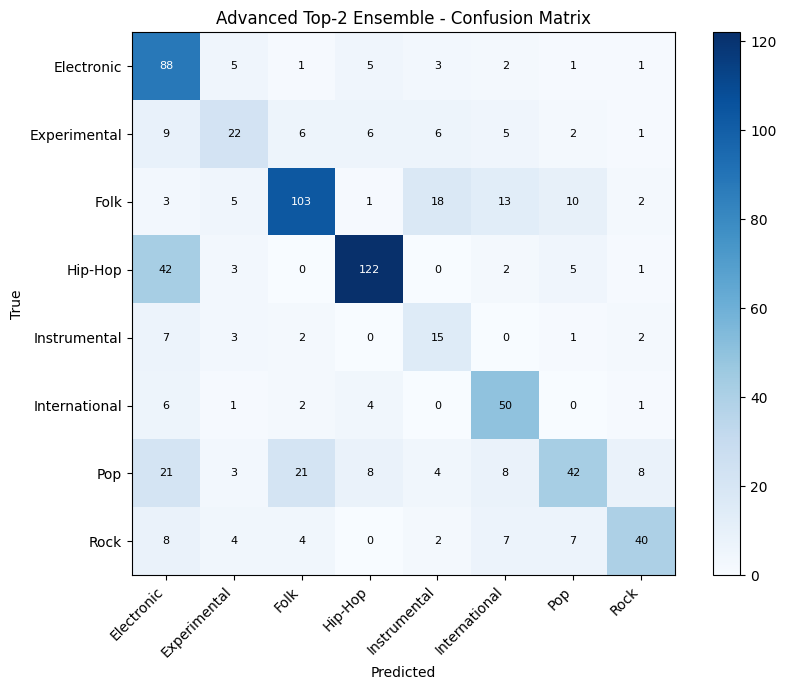

In [38]:
# Weighted top-2 ensemble evaluation (advanced models)

def predict_dataset(model, dataset):
    preds = []
    y_true_local = []
    for xb, yb in dataset:
        preds.append(model.predict(xb, verbose=0))
        y_true_local.extend(np.argmax(yb.numpy(), axis=1))
    return np.concatenate(preds, axis=0), np.array(y_true_local)


def best_val_acc_from_histories(histories):
    return max(max(h.history.get('val_accuracy', [0.0])) for h in histories)


if RUN_ADVANCED_TRAINING and 'adv_resnet_model' in globals() and 'adv_effnet_model' in globals():
    p_resnet, y_true_adv = predict_dataset(adv_resnet_model, val_adv)
    p_effnet, _ = predict_dataset(adv_effnet_model, val_adv)

    # Weight each model by best validation accuracy achieved during staged training
    w_resnet = best_val_acc_from_histories(hist_adv_resnet)
    w_effnet = best_val_acc_from_histories(hist_adv_effnet)
    w_sum = max(w_resnet + w_effnet, 1e-8)
    w_resnet, w_effnet = w_resnet / w_sum, w_effnet / w_sum

    p_ens = w_resnet * p_resnet + w_effnet * p_effnet
    y_pred_adv = np.argmax(p_ens, axis=1)
    ensemble_adv_acc = float(np.mean(y_pred_adv == y_true_adv))

    print(f'Advanced ResNet50 weight: {w_resnet:.3f}')
    print(f'Advanced EfficientNet weight: {w_effnet:.3f}')
    print(f'Advanced top-2 ensemble val_accuracy: {ensemble_adv_acc:.4f}')

    cm_adv = tf.math.confusion_matrix(y_true_adv, y_pred_adv, num_classes=len(class_names)).numpy()

    plt.figure(figsize=(9, 7))
    plt.imshow(cm_adv, cmap='Blues')
    plt.title('Advanced Top-2 Ensemble - Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')

    # Add numeric values inside each confusion-matrix cell
    threshold = cm_adv.max() / 2.0 if cm_adv.size else 0
    for i in range(cm_adv.shape[0]):
        for j in range(cm_adv.shape[1]):
            plt.text(
                j, i, f'{cm_adv[i, j]}',
                ha='center', va='center',
                color='white' if cm_adv[i, j] > threshold else 'black',
                fontsize=8
            )

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'advanced_ensemble_confusion_matrix.png', dpi=300)
    plt.show()
    
else:
    print('Run advanced staged training first (set RUN_ADVANCED_TRAINING=True).')

In [27]:
#SAVE THE BEST MODEL (based on advanced ensemble if available, else best single model)
if RUN_ADVANCED_TRAINING and 'ensemble_adv_acc' in locals():
    print(f'Saving advanced ensemble model with val_accuracy: {ensemble_adv_acc:.4f}')
    # Note: We can't save the ensemble directly, but we can save the individual models that compose it.
    adv_resnet_model.save(CHECKPOINT_DIR / 'final_adv_resnet50.keras')
    adv_effnet_model.save(CHECKPOINT_DIR / 'final_adv_effnetv2b0.keras')
else:
    # Save the best single model from previous comparisons
    best_model_name, best_metrics = sorted_results[0]
    print(f'Saving best single model: {best_model_name} with val_accuracy: {best_metrics["accuracy"]:.4f}')
    if 'Baseline' in best_model_name:
        baseline_model.save(CHECKPOINT_DIR / 'final_baseline.keras')
    elif 'Refined' in best_model_name:
        refined_model.save(CHECKPOINT_DIR / 'final_refined.keras')
    elif 'Fine-tuned EfficientNetV2-B0' in best_model_name:
        finetuned_model.save(CHECKPOINT_DIR / 'final_finetuned_effnetv2b0.keras')
    elif 'Fine-tuned ResNet50' in best_model_name:
        resnet_model.save(CHECKPOINT_DIR / 'final_finetuned_resnet50.keras')
    elif 'Hybrid' in best_model_name:
        hybrid_model.save(CHECKPOINT_DIR / 'final_hybrid.keras')
print('Model saving complete.')

Saving advanced ensemble model with val_accuracy: 0.6227
Model saving complete.


## Chunked Dataset + Song-Level Voting Utilities
Use this section after generating chunked spectrograms and split manifests.
- Loads leakage-safe chunk manifests (`train_manifest.csv`, `val_manifest.csv`)
- Builds TensorFlow datasets directly from manifest rows
- Evaluates chunk-level and song-level accuracy using probability averaging

In [30]:
# Manifest-based chunk loader + song-level voting evaluation
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path

CHUNK_IMG_SIZE = (224, 224)
CHUNK_BATCH_SIZE = 32

# Modes: 'auto', 'raw_rgb', 'engineered_3ch'
EVAL_INPUT_MODE = 'auto'

chunk_root = PROJECT_ROOT / 'processed_data' / 'spectrograms_chunked'
train_manifest_path = chunk_root / 'train_manifest.csv'
val_manifest_path = chunk_root / 'val_manifest.csv'


def resolve_manifest_path(raw_path, project_root):
    """Resolve Windows/Linux relative paths in manifest to a valid local path."""
    s = str(raw_path).strip().replace('\\', '/')
    p = Path(s)

    # 1) Absolute path that already exists
    if p.is_absolute() and p.exists():
        return str(p)

    # 2) Relative to PROJECT_ROOT
    cand = (project_root / p).resolve()
    if cand.exists():
        return str(cand)

    # 3) Re-anchor using known dataset marker
    marker = 'processed_data/spectrograms_chunked/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        cand2 = (project_root / 'processed_data' / 'spectrograms_chunked' / suffix).resolve()
        if cand2.exists():
            return str(cand2)

    # Return best attempt (for diagnostics)
    return str(cand)


def infer_input_mode(model, requested_mode='auto'):
    if requested_mode in ('raw_rgb', 'engineered_3ch'):
        return requested_mode

    model_name = getattr(model, 'name', '').lower()

    # Advanced focal models in this notebook are trained on engineered 3-channel inputs.
    engineered_hints = ('focal', 'adv_resnet', 'adv_effnet', 'engineered')
    if any(k in model_name for k in engineered_hints):
        return 'engineered_3ch'

    return 'raw_rgb'


def preprocess_chunk_image(path, mode):
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=3)
    x = tf.image.resize(x, CHUNK_IMG_SIZE)
    x = tf.cast(x, tf.float32) / 255.0

    if mode == 'raw_rgb':
        return x

    # Engineered 3-channel representation: grayscale + Sobel gradients
    gray = tf.image.rgb_to_grayscale(x)           # [H, W, 1]
    gray_b = tf.expand_dims(gray, axis=0)         # [1, H, W, 1]
    sobel = tf.image.sobel_edges(gray_b)          # [1, H, W, 1, 2]
    sobel = tf.squeeze(sobel, axis=0)             # [H, W, 1, 2]

    gx = sobel[..., 0]                            # [H, W, 1]
    gy = sobel[..., 1]                            # [H, W, 1]

    gx = tf.clip_by_value((gx + 1.0) * 0.5, 0.0, 1.0)
    gy = tf.clip_by_value((gy + 1.0) * 0.5, 0.0, 1.0)

    return tf.concat([gray, gx, gy], axis=-1)    # [H, W, 3]


if not train_manifest_path.exists() or not val_manifest_path.exists():
    print('Chunk manifests not found. Generate them with:')
    print('1) chunked_spectrogram_generator.py')
    print('2) build_track_level_split.py')
else:
    train_manifest = pd.read_csv(train_manifest_path)
    val_manifest = pd.read_csv(val_manifest_path)

    # Normalize paths from manifest and keep only existing files
    train_manifest['image_path'] = train_manifest['image_path'].apply(lambda p: resolve_manifest_path(p, PROJECT_ROOT))
    val_manifest['image_path'] = val_manifest['image_path'].apply(lambda p: resolve_manifest_path(p, PROJECT_ROOT))

    train_before = len(train_manifest)
    val_before = len(val_manifest)
    train_manifest = train_manifest[train_manifest['image_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)
    val_manifest = val_manifest[val_manifest['image_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)

    print(f'Train rows kept: {len(train_manifest)}/{train_before}')
    print(f'Val rows kept:   {len(val_manifest)}/{val_before}')

    if len(train_manifest) == 0 or len(val_manifest) == 0:
        print('No valid chunk files found after path resolution.')
        print('Verify chunk_root:', chunk_root)
    else:
        name_to_idx = {n: i for i, n in enumerate(class_names)}

        # Example usage with your current best GUI-integrated model name if available.
        # Change `model_for_voting` to any trained model object in this notebook.
        model_for_voting = None
        if 'adv_resnet_model' in globals():
            model_for_voting = adv_resnet_model
        elif 'resnet_model' in globals():
            model_for_voting = resnet_model
        elif 'finetuned_model' in globals():
            model_for_voting = finetuned_model

        if model_for_voting is None:
            print('No trained model object found in memory yet. Train/load one, then rerun this cell.')
        else:
            active_mode = infer_input_mode(model_for_voting, EVAL_INPUT_MODE)
            print(f'Using input mode: {active_mode} (requested={EVAL_INPUT_MODE})')
            print(f'Model name: {getattr(model_for_voting, "name", "unknown")}')

            def df_to_ds(df, mode, training=False):
                paths = df['image_path'].astype(str).tolist()
                labels = [name_to_idx[g] for g in df['genre'].astype(str).tolist()]
                ds = tf.data.Dataset.from_tensor_slices((paths, labels))

                def _decode(path, label):
                    x = preprocess_chunk_image(path, mode)
                    y = tf.one_hot(tf.cast(label, tf.int32), depth=len(class_names))
                    return x, y

                if training:
                    ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)
                ds = ds.map(_decode, num_parallel_calls=tf.data.AUTOTUNE)
                ds = ds.batch(CHUNK_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
                return ds

            train_chunk_ds = df_to_ds(train_manifest, mode=active_mode, training=True)
            val_chunk_ds = df_to_ds(val_manifest, mode=active_mode, training=False)

            print('Chunk train rows:', len(train_manifest), '| unique tracks:', train_manifest['track_id'].nunique())
            print('Chunk val rows:', len(val_manifest), '| unique tracks:', val_manifest['track_id'].nunique())

            def evaluate_song_level(model, manifest_df, mode, batch_size=64):
                paths = manifest_df['image_path'].astype(str).tolist()
                labels = manifest_df['genre'].astype(str).tolist()
                track_ids = manifest_df['track_id'].astype(int).tolist()

                name_to_idx_local = {n: i for i, n in enumerate(class_names)}

                ds = tf.data.Dataset.from_tensor_slices((paths, labels, track_ids))

                def _decode_eval(path, genre, tid):
                    x = preprocess_chunk_image(path, mode)
                    return x, genre, tid

                ds = ds.map(_decode_eval, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size)

                probs_by_track = {}
                true_by_track = {}

                for xb, genre_b, tid_b in ds:
                    pb = model.predict(xb, verbose=0)
                    for i in range(pb.shape[0]):
                        tid = int(tid_b[i].numpy())
                        genre_str = genre_b[i].numpy().decode('utf-8')
                        y_true = name_to_idx_local[genre_str]
                        probs_by_track.setdefault(tid, []).append(pb[i])
                        true_by_track[tid] = y_true

                y_true_song = []
                y_pred_song = []

                for tid, plist in probs_by_track.items():
                    avg_prob = np.mean(np.stack(plist, axis=0), axis=0)
                    pred = int(np.argmax(avg_prob))
                    y_pred_song.append(pred)
                    y_true_song.append(int(true_by_track[tid]))

                song_acc = float(np.mean(np.array(y_pred_song) == np.array(y_true_song)))
                return song_acc, y_true_song, y_pred_song

            chunk_loss, chunk_acc = model_for_voting.evaluate(val_chunk_ds, verbose=0)
            song_acc, y_true_song, y_pred_song = evaluate_song_level(model_for_voting, val_manifest, mode=active_mode)
            print(f'Chunk-level val_accuracy: {chunk_acc:.4f}')
            print(f'Song-level val_accuracy (probability voting): {song_acc:.4f}')

Train rows kept: 18552/18552
Val rows kept:   4644/4644
Using input mode: engineered_3ch (requested=auto)
Model name: resnet50_focal
Chunk train rows: 18552 | unique tracks: 3092
Chunk val rows: 4644 | unique tracks: 774
Chunk-level val_accuracy: 0.3144
Song-level val_accuracy (probability voting): 0.3243


In [33]:
# A/B check: raw RGB vs engineered 3-channel preprocessing
if 'model_for_voting' not in globals() or model_for_voting is None:
    print('Run Cell 33 first so model_for_voting is set.')
elif 'val_manifest' not in globals() or len(val_manifest) == 0:
    print('Run Cell 33 first so val_manifest is loaded and validated.')
else:
    local_name_to_idx = {n: i for i, n in enumerate(class_names)}

    def build_val_ds_for_mode(df, mode):
        paths = df['image_path'].astype(str).tolist()
        labels = [local_name_to_idx[g] for g in df['genre'].astype(str).tolist()]
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        def _decode(path, label):
            x = preprocess_chunk_image(path, mode)
            y = tf.one_hot(tf.cast(label, tf.int32), depth=len(class_names))
            return x, y

        return ds.map(_decode, num_parallel_calls=tf.data.AUTOTUNE).batch(CHUNK_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    mode_results = {}
    for mode in ['raw_rgb', 'engineered_3ch']:
        val_ds_mode = build_val_ds_for_mode(val_manifest, mode)
        _, chunk_acc_mode = model_for_voting.evaluate(val_ds_mode, verbose=0)
        song_acc_mode, _, _ = evaluate_song_level(model_for_voting, val_manifest, mode=mode)
        mode_results[mode] = {
            'chunk_acc': float(chunk_acc_mode),
            'song_acc': float(song_acc_mode),
        }
        print(f"{mode:15s} -> chunk_acc={chunk_acc_mode:.4f} | song_acc={song_acc_mode:.4f}")

    best_mode = max(mode_results.items(), key=lambda kv: kv[1]['song_acc'])[0]
    print(f"Best mode by song-level accuracy: {best_mode}")

    # Optional: persist the preferred mode for Cell 33 reruns
    EVAL_INPUT_MODE = best_mode
    print(f"Set EVAL_INPUT_MODE = '{EVAL_INPUT_MODE}'")

raw_rgb         -> chunk_acc=0.0919 | song_acc=0.0814
engineered_3ch  -> chunk_acc=0.5898 | song_acc=0.6525
Best mode by song-level accuracy: engineered_3ch
Set EVAL_INPUT_MODE = 'engineered_3ch'


## Chunk Retraining On Manifest (Engineered Pipeline)
This section retrains a ResNet50 focal model directly on chunk manifests with the same engineered 3-channel preprocessing used in evaluation.
- Uses leakage-safe `train_manifest` / `val_manifest`
- Uses engineered preprocessing (`grayscale + Sobel gradients`)
- Recomputes class-balanced focal loss from chunk labels
- Runs short staged fine-tuning and reports chunk/song metrics

In [32]:
# Retrain directly on chunk manifests with engineered preprocessing
if 'train_manifest' not in globals() or 'val_manifest' not in globals():
    print('Run Cell 33 first to load and validate train_manifest/val_manifest.')
else:
    CHUNK_RETRAIN_BATCH = 32
    CHUNK_RETRAIN_STAGE1_EPOCHS = 3
    CHUNK_RETRAIN_STAGE2_EPOCHS = 4

    name_to_idx_chunk = {n: i for i, n in enumerate(class_names)}

    # Recompute class-balanced alpha from chunk training labels
    chunk_labels = np.array([name_to_idx_chunk[g] for g in train_manifest['genre'].astype(str).tolist()], dtype=np.int32)
    chunk_counts = np.bincount(chunk_labels, minlength=len(class_names)).astype(np.float32)
    chunk_alpha = chunk_counts.sum() / np.maximum(chunk_counts, 1.0)
    chunk_alpha = chunk_alpha / chunk_alpha.sum() * len(class_names)
    chunk_alpha_tf = tf.constant(chunk_alpha, dtype=tf.float32)

    def focal_loss_chunk(y_true, y_pred, gamma=2.0):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        modulating = tf.pow(1.0 - y_pred, gamma)
        alpha_factor = y_true * chunk_alpha_tf
        focal = alpha_factor * modulating * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))

    def build_chunk_ds(df, training=False):
        paths = df['image_path'].astype(str).tolist()
        labels = np.array([name_to_idx_chunk[g] for g in df['genre'].astype(str).tolist()], dtype=np.int32)
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        def _decode(path, label):
            x = preprocess_chunk_image(path, mode='engineered_3ch')
            y = tf.one_hot(tf.cast(label, tf.int32), depth=len(class_names))
            return x, y

        if training:
            ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)
        ds = ds.map(_decode, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(CHUNK_RETRAIN_BATCH).prefetch(tf.data.AUTOTUNE)
        return ds

    train_chunk_eng_ds = build_chunk_ds(train_manifest, training=True)
    val_chunk_eng_ds = build_chunk_ds(val_manifest, training=False)

    # Build a fresh chunk model
    chunk_resnet_model, chunk_resnet_base = build_backbone_model(
        backbone='resnet50',
        input_shape=(CHUNK_IMG_SIZE[0], CHUNK_IMG_SIZE[1], 3),
        num_classes=len(class_names)
    )

    # Stage 1: frozen backbone
    chunk_resnet_base.trainable = False
    chunk_resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss_chunk,
        metrics=['accuracy']
    )

    print('Chunk retraining stage 1 (frozen backbone)...')
    history_chunk_stage1 = chunk_resnet_model.fit(
        train_chunk_eng_ds,
        validation_data=val_chunk_eng_ds,
        epochs=CHUNK_RETRAIN_STAGE1_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / 'chunk_retrain_stage1_best.keras'),
                monitor='val_accuracy',
                save_best_only=True,
            ),
        ],
        verbose=1,
    )

    # Stage 2: unfreeze top layers
    chunk_resnet_base.trainable = True
    for layer in chunk_resnet_base.layers[:-30]:
        layer.trainable = False

    chunk_resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7e-5),
        loss=focal_loss_chunk,
        metrics=['accuracy']
    )

    print('Chunk retraining stage 2 (fine-tuning top layers)...')
    history_chunk_stage2 = chunk_resnet_model.fit(
        train_chunk_eng_ds,
        validation_data=val_chunk_eng_ds,
        epochs=CHUNK_RETRAIN_STAGE2_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / 'chunk_retrain_stage2_best.keras'),
                monitor='val_accuracy',
                save_best_only=True,
            ),
        ],
        verbose=1,
    )

    # Evaluate and promote model for downstream A/B checks
    chunk_loss_new, chunk_acc_new = chunk_resnet_model.evaluate(val_chunk_eng_ds, verbose=0)
    song_acc_new, _, _ = evaluate_song_level(chunk_resnet_model, val_manifest, mode='engineered_3ch')

    print(f'Chunk retrained model -> chunk_acc={chunk_acc_new:.4f}, song_acc={song_acc_new:.4f}')

    model_for_voting = chunk_resnet_model
    EVAL_INPUT_MODE = 'engineered_3ch'
    print("Set model_for_voting = chunk_resnet_model and EVAL_INPUT_MODE = 'engineered_3ch'")

Chunk retraining stage 1 (frozen backbone)...
Epoch 1/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 1318s 2s/step - accuracy: 0.4403 - loss: 0.9453 - val_accuracy: 0.4998 - val_loss: 0.7667
Epoch 2/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.5243 - loss: 0.7191 - val_accuracy: 0.5739 - val_loss: 0.6987
Epoch 3/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.5576 - loss: 0.6603 - val_accuracy: 0.5883 - val_loss: 0.7100
Chunk retraining stage 2 (fine-tuning top layers)...
Epoch 1/4
580/580 ━━━━━━━━━━━━━━━━━━━━ 71s 88ms/step - accuracy: 0.5681 - loss: 0.6309 - val_accuracy: 0.5898 - val_loss: 0.6762
Epoch 2/4
580/580 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.6979 - loss: 0.3973 - val_accuracy: 0.6275 - val_loss: 0.7416
Epoch 3/4
580/580 ━━━━━━━━━━━━━━━━━━━━ 37s 64ms/step - accuracy: 0.7920 - loss: 0.2543 - val_accuracy: 0.6249 - val_loss: 0.8197
Chunk retrained model -> chunk_acc=0.5898, song_acc=0.6525
Set model_for_voting = chunk_resnet_model and EVAL_INPUT_MODE = 'eng

## Chunk Model Deep-Dive (Extra Fine-Tune + Confusion Matrix + Save)
This cell continues fine-tuning the chunk-retrained model, reports confusion matrix and per-genre recall, and saves a final checkpoint for GUI deployment.

Extra fine-tuning for 3 epochs...
Epoch 1/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.7167 - loss: 0.3656 - val_accuracy: 0.6212 - val_loss: 0.6602
Epoch 2/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 35s 60ms/step - accuracy: 0.8033 - loss: 0.2452 - val_accuracy: 0.6251 - val_loss: 0.7057
Epoch 3/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.8718 - loss: 0.1693 - val_accuracy: 0.6234 - val_loss: 0.7680
Final chunk model -> chunk_acc=0.6212, song_acc=0.6990

Per-genre recall (song-level):
  Electronic    : 0.7547
  Experimental  : 0.5263
  Folk          : 0.7161
  Hip-Hop       : 0.8457
  Instrumental  : 0.5000
  International : 0.7969
  Pop           : 0.4870
  Rock          : 0.6944


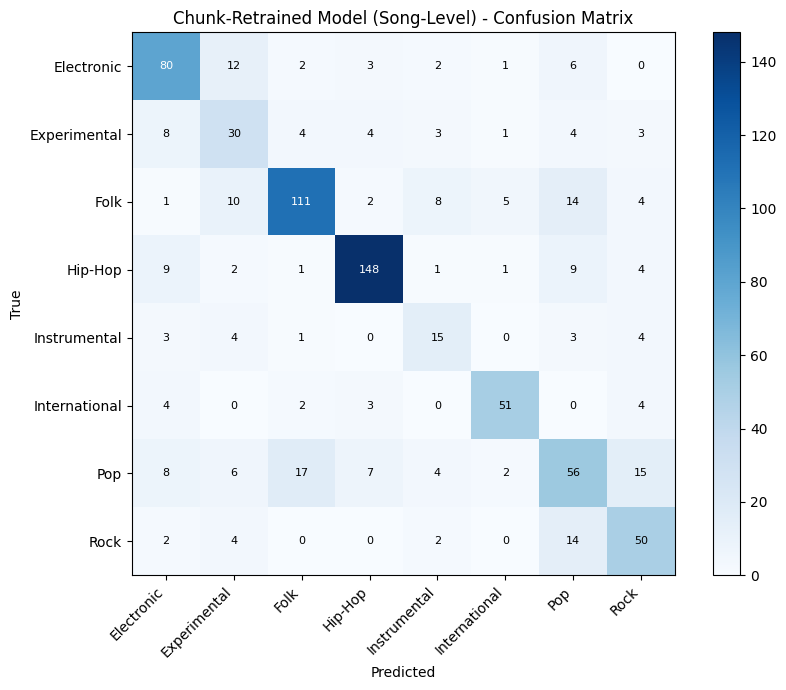

Saved final chunk model: /content/drive/MyDrive/Senior Project 2/model_checkpoints/final_chunk_retrained_resnet50.keras


In [34]:
# Continue fine-tuning + diagnostics + final save for GUI use
if 'chunk_resnet_model' not in globals():
    print('Run Cell 36 first to train chunk_resnet_model.')
elif 'train_chunk_eng_ds' not in globals() or 'val_chunk_eng_ds' not in globals():
    print('Run Cell 36 first to build chunk datasets.')
else:
    EXTRA_FINE_TUNE_EPOCHS = 3

    # Keep only top layers trainable for stable fine-tuning
    chunk_resnet_base.trainable = True
    for layer in chunk_resnet_base.layers[:-20]:
        layer.trainable = False

    chunk_resnet_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-5),
        loss=focal_loss_chunk,
        metrics=['accuracy']
    )

    print(f'Extra fine-tuning for {EXTRA_FINE_TUNE_EPOCHS} epochs...')
    history_chunk_stage3 = chunk_resnet_model.fit(
        train_chunk_eng_ds,
        validation_data=val_chunk_eng_ds,
        epochs=EXTRA_FINE_TUNE_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(
                filepath=str(CHECKPOINT_DIR / 'chunk_retrain_stage3_best.keras'),
                monitor='val_accuracy',
                save_best_only=True,
            ),
        ],
        verbose=1,
    )

    # Final metrics
    chunk_loss_final, chunk_acc_final = chunk_resnet_model.evaluate(val_chunk_eng_ds, verbose=0)
    song_acc_final, y_true_song_final, y_pred_song_final = evaluate_song_level(
        chunk_resnet_model,
        val_manifest,
        mode='engineered_3ch'
    )

    print(f'Final chunk model -> chunk_acc={chunk_acc_final:.4f}, song_acc={song_acc_final:.4f}')

    # Song-level confusion matrix + per-genre recall
    cm_song = tf.math.confusion_matrix(
        y_true_song_final,
        y_pred_song_final,
        num_classes=len(class_names)
    ).numpy()

    recalls = {}
    for i, name in enumerate(class_names):
        denom = float(cm_song[i, :].sum())
        recalls[name] = (float(cm_song[i, i]) / denom) if denom > 0 else 0.0

    print('\nPer-genre recall (song-level):')
    for name in class_names:
        print(f'  {name:14s}: {recalls[name]:.4f}')

    plt.figure(figsize=(9, 7))
    plt.imshow(cm_song, cmap='Blues')
    plt.title('Chunk-Retrained Model (Song-Level) - Confusion Matrix')
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')

    threshold = cm_song.max() / 2.0 if cm_song.size else 0
    for i in range(cm_song.shape[0]):
        for j in range(cm_song.shape[1]):
            plt.text(
                j, i, f'{cm_song[i, j]}',
                ha='center', va='center',
                color='white' if cm_song[i, j] > threshold else 'black',
                fontsize=8
            )

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'chunk_retrained_song_confusion_matrix.png', dpi=300)
    plt.show()

    # Save final checkpoint candidate for GUI default loading
    final_chunk_model_path = CHECKPOINT_DIR / 'final_chunk_retrained_resnet50.keras'
    chunk_resnet_model.save(final_chunk_model_path)
    print(f'Saved final chunk model: {final_chunk_model_path}')

    # Promote as active predictor target
    model_for_voting = chunk_resnet_model
    EVAL_INPUT_MODE = 'engineered_3ch'

In [35]:
# Top confusion pairs (song-level) for targeted improvement
if 'cm_song' not in globals():
    if 'y_true_song_final' in globals() and 'y_pred_song_final' in globals():
        cm_song = tf.math.confusion_matrix(
            y_true_song_final,
            y_pred_song_final,
            num_classes=len(class_names)
        ).numpy()
    else:
        print('Run Cell 38 first to generate song-level predictions/confusion matrix.')

if 'cm_song' in globals():
    confusions = []
    for true_i, true_name in enumerate(class_names):
        row_total = int(np.sum(cm_song[true_i, :]))
        if row_total == 0:
            continue
        for pred_i, pred_name in enumerate(class_names):
            if pred_i == true_i:
                continue
            count = int(cm_song[true_i, pred_i])
            if count <= 0:
                continue
            rate = count / row_total
            confusions.append({
                'true': true_name,
                'pred': pred_name,
                'count': count,
                'rate_within_true': rate,
            })

    if not confusions:
        print('No off-diagonal confusions found.')
    else:
        confusions = sorted(confusions, key=lambda x: (x['count'], x['rate_within_true']), reverse=True)
        top_k = 10
        print(f'Top {min(top_k, len(confusions))} confusion pairs (song-level):')
        for i, item in enumerate(confusions[:top_k], 1):
            print(
                f"{i:2d}. {item['true']} -> {item['pred']} | "
                f"count={item['count']}, rate={item['rate_within_true']:.3f}"
            )

Top 10 confusion pairs (song-level):
 1. Pop -> Folk | count=17, rate=0.148
 2. Pop -> Rock | count=15, rate=0.130
 3. Rock -> Pop | count=14, rate=0.194
 4. Folk -> Pop | count=14, rate=0.090
 5. Electronic -> Experimental | count=12, rate=0.113
 6. Folk -> Experimental | count=10, rate=0.065
 7. Hip-Hop -> Electronic | count=9, rate=0.051
 8. Hip-Hop -> Pop | count=9, rate=0.051
 9. Experimental -> Electronic | count=8, rate=0.140
10. Pop -> Electronic | count=8, rate=0.070
